In [7]:
import seaborn as sns

In [8]:
df=sns.load_dataset('tips')

In [9]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [11]:
df[df["total_bill"]>20]

,total_bill,tip,sex,smoker,day,time,size
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
5,25.29,4.71,Male,No,Sun,Dinner,4
7,26.88,3.12,Male,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
237,32.83,1.17,Male,Yes,Sat,Dinner,2
238,35.83,4.67,Female,No,Sat,Dinner,3
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2


In [12]:
df.isna().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [13]:
avg_tip=df.groupby('day')["tip"].mean()
avg_tip

day
Thur    2.771452
Fri     2.734737
Sat     2.993103
Sun     3.255132
Name: tip, dtype: float64

In [14]:
df.pivot_table(values='tip',index="day",columns='time',aggfunc='mean')

time,Lunch,Dinner
day,,
Thur,2.767705,3.000000
Fri,2.382857,2.940000
Sat,NaN,2.993103
Sun,NaN,3.255132


In [20]:
df['tip_percent']=df.apply(lambda row: row['tip']/row['total_bill']*100,axis=1)

Text(0.5, 1.0, 'Total Bills by Day')

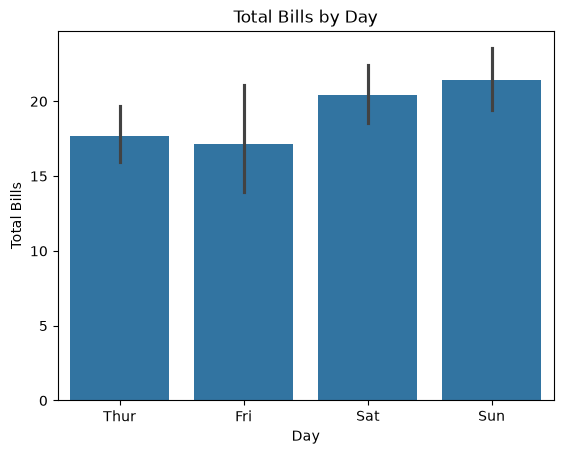

In [16]:
import matplotlib.pyplot as plt
sns.barplot(data=df,x='day',y='total_bill')
plt.xlabel('Day')
plt.ylabel('Total Bills')
plt.title('Total Bills by Day')

Text(0.5, 1.0, 'Total Bill vs Tips')

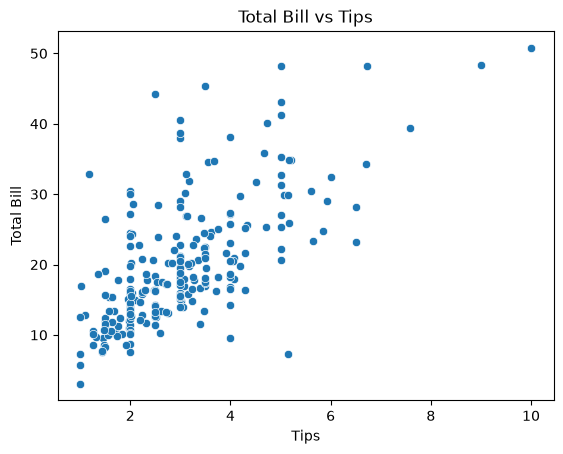

In [17]:
sns.scatterplot(data=df,x='tip',y='total_bill')
plt.xlabel('Tips')
plt.ylabel('Total Bill')
plt.title('Total Bill vs Tips')

Text(0.5, 1.0, 'Correlation Matrix')

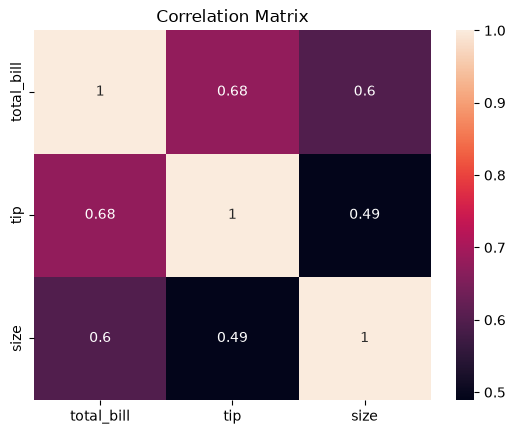

In [18]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.title('Correlation Matrix')

In [19]:
df['tip'].describe()

count    244.000000
mean       2.998279
std        1.383638
min        1.000000
25%        2.000000
50%        2.900000
75%        3.562500
max       10.000000
Name: tip, dtype: float64

In [21]:
print(df['tip_percent'])

0       5.944673
1      16.054159
2      16.658734
3      13.978041
4      14.680765
         ...    
239    20.392697
240     7.358352
241     8.822232
242     9.820426
243    15.974441
Name: tip_percent, Length: 244, dtype: float64


Text(0.5, 1.0, 'Histogram')

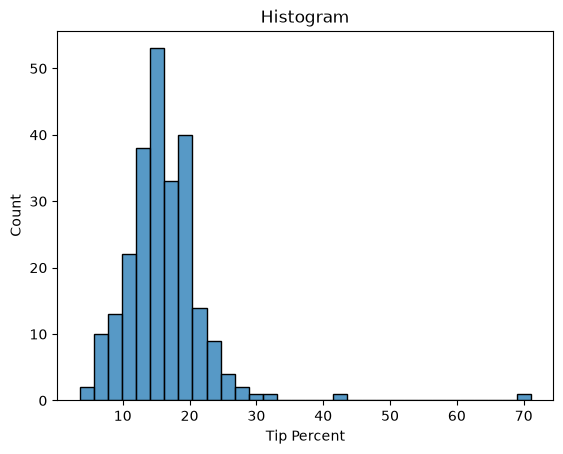

In [24]:
sns.histplot(data=df,x='tip_percent')
plt.xlabel('Tip Percent')
plt.title('Histogram')

<Axes: xlabel='tip_percent'>

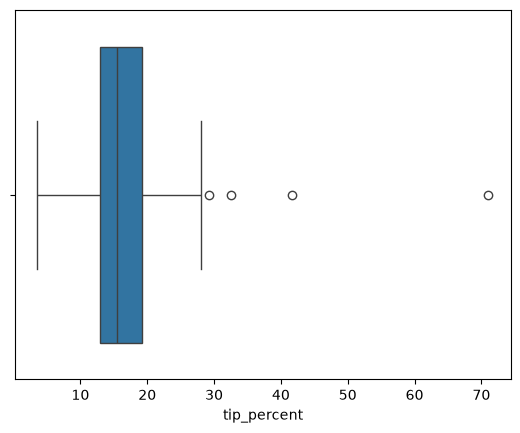

In [25]:
sns.boxplot(data=df,x='tip_percent')


In [26]:
correlation=df[['total_bill','tip']].corr
correlation

<bound method DataFrame.corr of      total_bill   tip
0         16.99  1.01
1         10.34  1.66
2         21.01  3.50
3         23.68  3.31
4         24.59  3.61
..          ...   ...
239       29.03  5.92
240       27.18  2.00
241       22.67  2.00
242       17.82  1.75
243       18.78  3.00

[244 rows x 2 columns]>

In [28]:
from scipy import stats

In [29]:
smokers=df[df['smoker'] == 'Yes']['tip_percent']
non_smokers=df[df['smoker'] == 'No']['tip_percent']

In [30]:
smokers

56      7.892660
58     15.658363
60     15.820601
61     14.482259
62     17.967332
         ...    
234    19.317450
236     7.936508
237     3.563814
240     7.358352
241     8.822232
Name: tip_percent, Length: 93, dtype: float64

In [31]:
non_smokers

0       5.944673
1      16.054159
2      16.658734
3      13.978041
4      14.680765
         ...    
235    12.413108
238    13.033771
239    20.392697
242     9.820426
243    15.974441
Name: tip_percent, Length: 151, dtype: float64

In [32]:
t_stat, p_value = stats.ttest_ind(smokers,non_smokers, equal_var=False)

print('T-statistic:', t_stat)
print('P-value:', p_value)

T-statistic: 0.4112251378479481
P-value: 0.6816579190889744


In [33]:
if p_value < 0.05:
    print('The difference is statistically significant.')
else:
    print('The difference is not statistically significant.')

The difference is not statistically significant.
